##BEGGINING OF SORTH PATH.

###CLASS

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import sys
import os

##MATRIZ ADYACENCIA

In [ ]:
#A = np.array([[0, 4, 3, np.inf, np.inf, np.inf, np.inf, np.inf],
#             [4, 0, 2, 5, np.inf, np.inf, np.inf, np.inf],
#              [3, 2, 0, 3, 6, np.inf, np.inf, np.inf],
#              [np.inf, 5, 3, 0, 1, 5, np.inf, np.inf],
#              [np.inf, np.inf, 6, 1, 0, np.inf, 5, np.inf],
#              [np.inf, np.inf, np.inf, 5, np.inf, 0, 2, 7],
#              [np.inf, np.inf, np.inf, np.inf, 5, 2, 0, 4],
#              [np.inf, np.inf, np.inf, np.inf, np.inf, 7, 4, 0]])
A = np.array([
    [0, 10, 10, 50, np.inf, np.inf, np.inf, np.inf],
    [10, 0,  100, 12,  np.inf, np.inf, np.inf, np.inf],
    [10, 100, 0, np.inf, 20,  np.inf, np.inf, np.inf],
    [50, 12, np.inf, 0, 52, 23, np.inf, np.inf],
    [np.inf, np.inf, 20, 52,  0, np.inf, 21, np.inf],
    [np.inf, np.inf, np.inf, 23, np.inf, 0, 102, 24],
    [np.inf, np.inf, np.inf, np.inf, 21, 102, 0, 90],
    [np.inf, np.inf, np.inf, np.inf, np.inf, 24, 90, 0]
])

pg = 1  # primer gen, es el punto de salida
ug = 7 # ultimo gen, es el punto final o de llegada, este es fijo.
nc = len(A)  # numero de genes de cada cromosoma
mejora = []  # lista que guarda el mejor costo en cada iteración.

#EXAMPLE

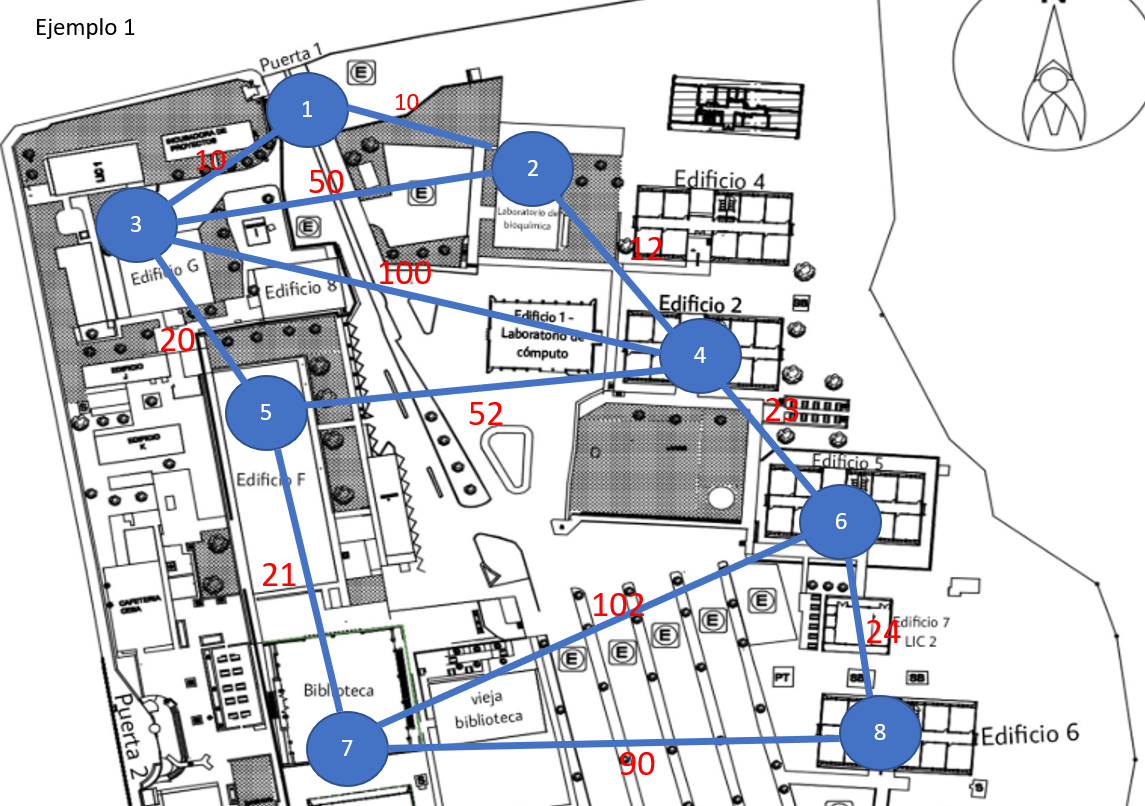

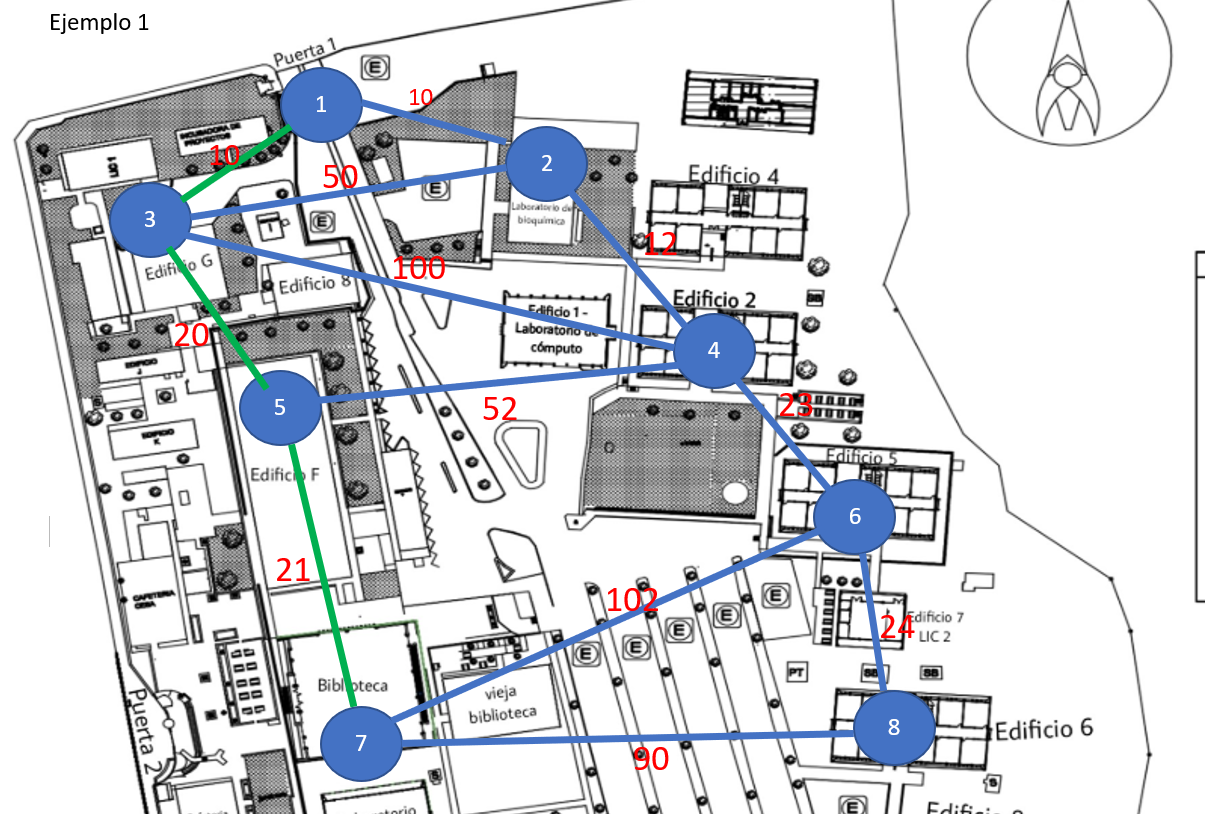

#Beginning of functions

El mejor individuo es: [1, 3, 5, 7].
Su recorrido es: 51.0m
El tiempo de ejecucion es: 0.6322813034057617 segundos.


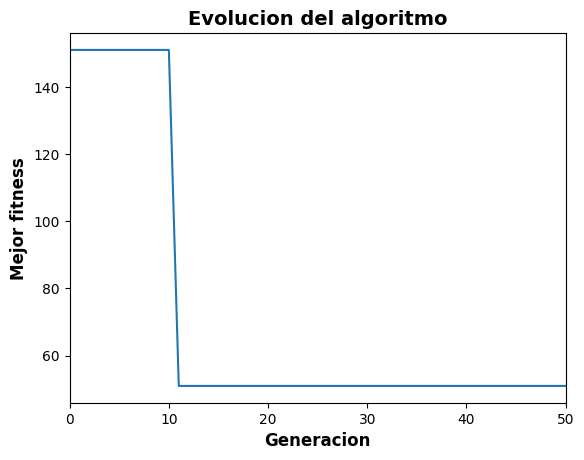

In [ ]:
class AG(object):
    def __init__(self, Npop, Nit, mu, xrat, Verbose=True):
        self.Npop = Npop  # numero de cromosomas
        self.Nit = Nit  # numero de iteraciones
        self.mu = mu  # tasa de mutacion
        self.xrat = xrat  # tasa de cruzamiento
        self.Nkeep = int(np.ceil(xrat * Npop))  # numero de cromosomas que se mantienen
        self.Verbose = Verbose  # imprimir resultados

    def poblacion(self):
        y = np.array([[random.randint(1, nc-1) for i in range(nc-2)] for j in range(self.Npop)])
        return y

    def probabilidad(self):
        p = np.array(range(1, self.Nkeep + 1))
        p = (self.Nkeep - p + 1) / sum(p)
        for i in range(1, self.Nkeep):
            p[i] = p[i] + p[i - 1]
        return p

    def seleccion(self, p):
        u = random.random()
        if 0 <= u <= p[0]:
            y = 0
        else:
            for i in range(1, len(p)):
                if p[i - 1] < u <= p[i]:
                    y = i
                    break
        return y

    def cruce(self, A, B):
        y = np.zeros(len(A))
        l = len(A) - 2
        r = random.randint(1, l)
        u = random.random()
        if u <= 0.5:
            y[0:r + 1] = A[0:r + 1]
            y[r + 1:] = B[r + 1:]
        else:
            y[0:r + 1] = B[0:r + 1]
            y[r + 1:] = A[r + 1:]
        return y

    def cruce_poblacion(self, pop, p):
        for i in range(self.Nkeep, self.Npop):
            pop[i, :] = self.cruce(pop[self.seleccion(p), :], pop[self.seleccion(p), :])
        return pop

    def mutacion(self, pop):
        n = int(np.floor(self.mu * self.Npop * (nc - 2)))
        for i in range(n):
            M1 = random.randint(0, self.Npop - 1)
            M2 = random.randint(0, nc - 3)
            pop[M1, M2] = random.randint(1, nc - 1)
        return pop

    def f(self, x):
        x = list(x)
        x.insert(0, pg - 1)
        x.append(ug - 1)
        d = 0
        for i in range(0, nc - 1):
            d = d + A[x[i], x[i + 1]]
            if d == np.inf:
                break
        return d

    def evolucion(self):
        pop = self.poblacion()
        z = np.zeros(self.Npop)
        P = self.probabilidad()
        d = 0
        while d < self.Nit:
            for j in range(self.Npop):
                z[j] = self.f(pop[j, :])
            indice = np.argsort(z)
            z = np.sort(z)
            mejora.append(z[0])
            pop = pop[indice]
            pop = self.cruce_poblacion(pop, P)
            pop = self.mutacion(pop)
            d += 1

        indice = np.argsort(z)
        z = np.sort(z)
        mejora.append(z[0])
        y = pop[indice]

        z = list(y[0, :] + 1)
        z.insert(0, pg)
        z.append(ug)

        SOL = [pg]
        for t in range(1, nc):
            if z[t] != z[t - 1]:
                SOL.append(int(z[t]))

        print("El mejor individuo es: " + str(SOL) + ".")
        print("Su recorrido es: " + str(self.f(y[0, :])) + "m")

        plt.ion()
        plt.plot(mejora)
        plt.title("Evolucion del algoritmo", fontweight="bold", fontsize=14)
        plt.xlabel("Generacion", fontweight="bold", fontsize=12)
        plt.ylabel("Mejor fitness", fontweight="bold", fontsize=12)
        plt.xlim(0, self.Nit)

def main():
    import time
    start = time.time()
    algoritmo = AG(Npop=180, Nit=50, mu=0.02, xrat=0.5, Verbose=True)
    algoritmo.evolucion()
    end = time.time()
    print("El tiempo de ejecucion es: " + str(end - start) + " segundos.")

if __name__ == "__main__":
    main()

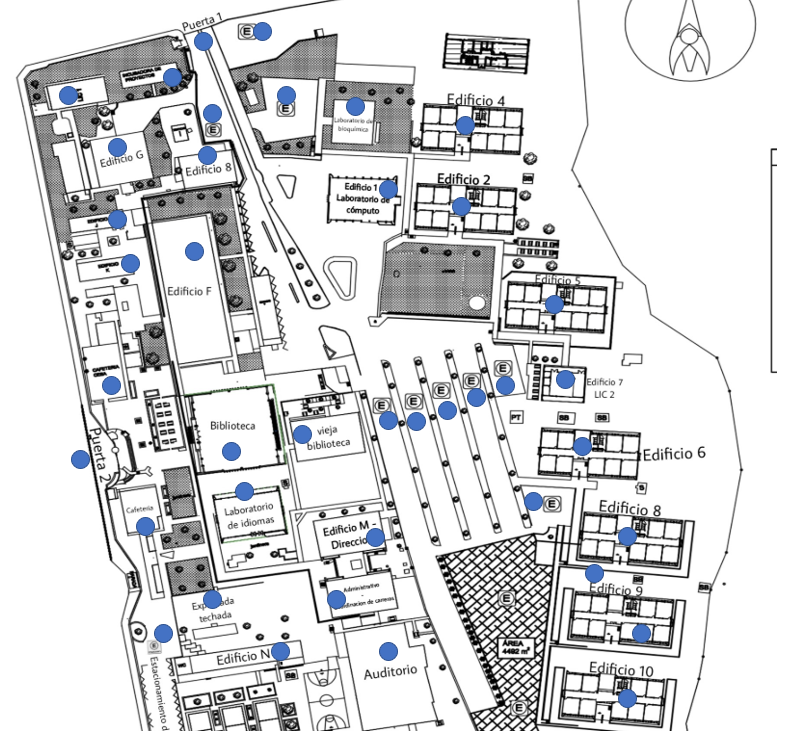